# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas as pd
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the discretization and diffusion parameter values
Discretizations= np.loadtxt(
    "../DATA_reaction/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA_reaction/diffusion.txt"
).astype(
    int
)

In [4]:
# introduction of the high fidelity part of the dataset
file_path_HF = "../DATA_reaction/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

# I consider only the reaction term as a variable
U_HF_test = U_HF_test[:, -1, 44,44]
# normalization of the data
reaction_HF_test = normalization(reaction_HF_test)
U_HF_test=normalization(U_HF_test)

# transformation of the dataseet
reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

In [5]:
# data augmentation introducing a noise
noise_stddev1=[0.01,0.005,0.02,0.005]
noise_stddev2=[0.005,0.003,0.01,0.003]

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

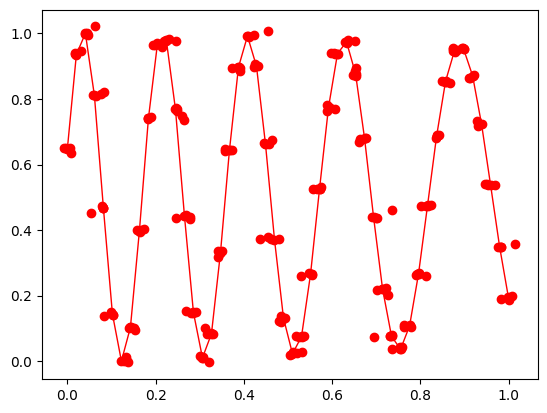

In [6]:
# plot of the new dataset
plt.plot(reaction_HF_test[:,0], U_HF_test, "ro", linewidth=1, label="HF model with noise")
plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, "r-", linewidth=1, label="HF model")
plt.show()

In [7]:
# Number of data of High and Low Fidelity components of the dataset
n_HF = np.array([100])
Nlf = np.array([200])

batch_size=[200,100]


In [8]:
U_LF_list = []
U_HF_list = []
# number of epochs 
Nepo=[7,8]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pd.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pd.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pd.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pd.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE



## Neural Network
Cycle on the Discretization and the value of the diffusion 

In [9]:
diffusion_best=np.array([diffusion[2]])
print(diffusion_best)

[75]


In [10]:
Discretizations_best=np.array([Discretizations[0]])

Folder '2_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
HPO name  LF


[I 2024-08-15 22:02:44,938] A new study created in RDB with name: no-name-13b2df39-7722-4e62-a7c8-03d2826cdc3f
[I 2024-08-15 22:03:05,049] Trial 1 finished with value: 1.2880098302737433 and parameters: {'nodes': 23, 'l2weight': 0.0006651901519020473, 'lr': 0.008728833423022062, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 1.2880098302737433.
[I 2024-08-15 22:03:05,828] Trial 0 finished with value: 0.2769085194212141 and parameters: {'nodes': 41, 'l2weight': 0.06840442438279248, 'lr': 0.014542529201910839, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 0 with value: 0.2769085194212141.
[I 2024-08-15 22:03:05,865] Trial 2 finished with value: 3.5309199522182464 and parameters: {'nodes': 33, 'l2weight': 0.0006161623812442325, 'lr': 0.00011668269708722592, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 0 with value: 0.2769085194212141.
[I 2024-08-15 22:03:05,914] Trial 3 finished with value: 0.1591223532848992 and parameters: {'no

The function training took 1.626890 seconds.


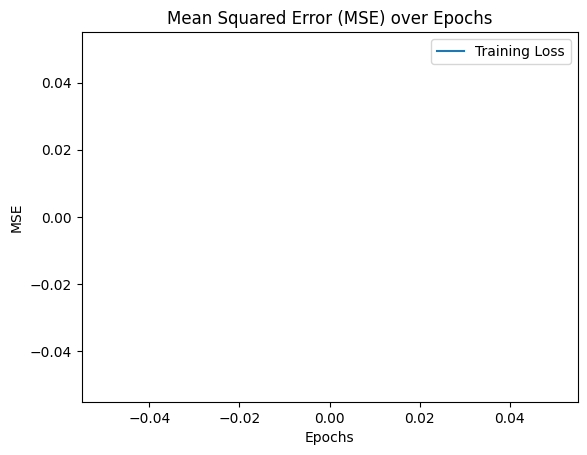

[I 2024-08-15 22:03:08,186] A new study created in RDB with name: no-name-77eabf5d-15c4-4db7-b44d-344cab87abbd


HPO name  HF


[I 2024-08-15 22:03:11,046] Trial 2 finished with value: 0.15417818482317214 and parameters: {'nodes': 42, 'l2weight': 0.0009409129112848554, 'lr': 0.0010251225383552968, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 2 with value: 0.15417818482317214.
[I 2024-08-15 22:03:11,484] Trial 1 finished with value: 0.12368727510589342 and parameters: {'nodes': 11, 'l2weight': 0.0010965078432507993, 'lr': 0.0011833102765379337, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 1 with value: 0.12368727510589342.
[I 2024-08-15 22:03:22,616] Trial 0 finished with value: 0.16140501650973063 and parameters: {'nodes': 5, 'l2weight': 0.00020029730104918382, 'lr': 0.010545000143576545, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.12368727510589342.
[I 2024-08-15 22:03:22,839] Trial 3 finished with value: 0.5616032955204904 and parameters: {'nodes': 4, 'l2weight': 0.00037397892987055096, 'lr': 0.0069508075569457844, 'kernel_init': 'glorot_uniform', '

The function training took 1.305382 seconds.


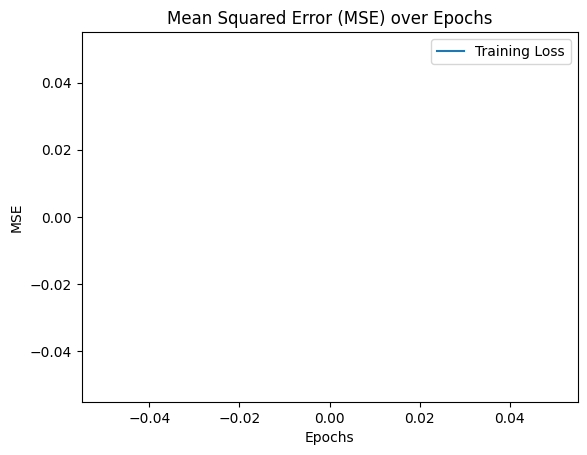

low fidelity NN
Test MSE: 0.14985035826482235
R^2: -0.20282342101201145
Final model
Test MSE: 0.113036652329578
R^2: 0.0014323003787691801


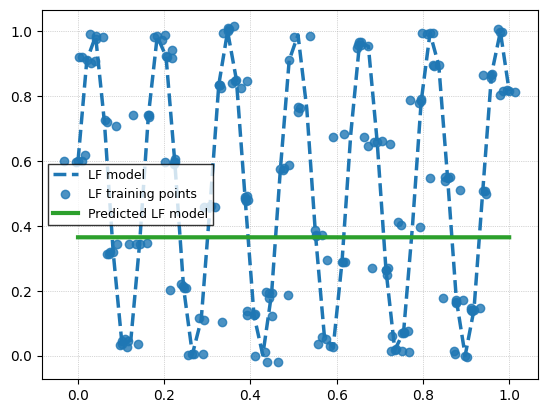

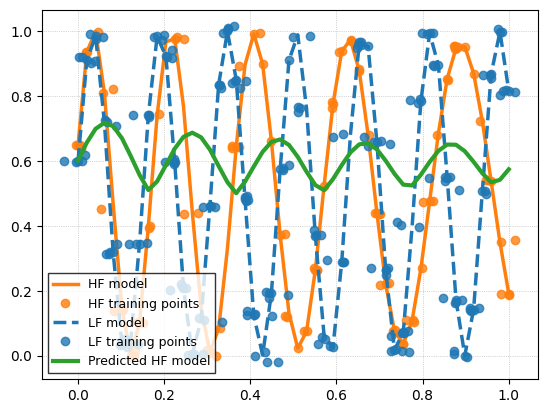

Empty DataFrame
Columns: [Discretization, diffusion, R2]
Index: []
Empty DataFrame
Columns: [Discretization, diffusion, MSE]
Index: []


In [11]:
# Name of the folder
folder_name = "2_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               
for m in range(len(Discretizations_best)):
    test_mse_HF_list = []
    test_mse_LF_list = []

    r2_HF_list = []
    r2_LF_list = []

    for d in range(len(diffusion_best)):
        for nhf in n_HF:
            for nlf in Nlf:
        
                print(
                f"********************  # Nb. nodes = {Discretizations_best[m]}  ********************"
                )
                
                print(
                f"********************  # Diff: = {diffusion_best[d]}  ********************"
                )
                
                print(
                f"********************  # NHF: = {nhf}  ********************"
                )
                print(
                f"********************  # NLF: = {nlf}  ********************"
                )
                ### import of the Low Fidelity component of the dataset 
                file_path_LF = "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

                # selection and normalization of the dataset
                U_LF_test = U_LF_test[:,- 1,int(4*(Discretizations[m]-1)/9),int(4*(Discretizations[m]-1)/9)] # indexes to find the same temporal (last) and spatial points        
                U_LF_test = normalization(U_LF_test)
                reaction_LF_test = normalization(reaction_LF_test)
                
                # transformation of the Low fidelity test set
                reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                U_LF_test_original=U_LF_test # keep the original for later evaluation and representation 
                
                # dataset augmentation adding a noise
                noise_std1=[0.02,0.01,0.02,0.01]
                noise_std2=[0.01,0.005,0.01,0.005]
                (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                
                # randomization and selection of the training set
                permutation = np.random.permutation(len(reaction_HF_test))
                reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                U_HF = U_HF_test[permutation][0:nhf]
                permutation = np.random.permutation(len(reaction_LF_test))
                reaction_LF = reaction_LF_test[permutation][0:nlf]
                U_train_LF = U_LF_test[permutation][0:nlf]

                # transformation of the dataset
                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                
                ##########################      Neural Network     ##########################
                K.clear_session()
                
                # parameters 
                bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
                best_params={'kernel_init': 'uniform', 
                             'l2weight': 0.005395541657336886, 
                             'lr': 0.0025412188591473228, 
                             'nodes': 12.0, 
                             'opt': 'Adamax'}


                # Multifidelity network 
                names=["LF","HF"]
                params=[bestLF_params, best_params]
                data_train=[reaction_LF, reaction_HF]
                output_train=[U_train_LF,U_HF]

                definition_2steps = {
                                    "network_type": "2step",
                                    "names": names,
                                    "params": params,
                                    "data_train": data_train,
                                    "output_train": output_train,
                                    "N": Nepo,
                                    "n": batch_size,
                                    "train": True,
                                    "do_HPO": True,
                                    "verbose": False
                                    }
                model= NetworkFactory.build_network(**definition_2steps)
  

  
                ULF = model.model_list[0].prediction(reaction_LF_test_original)
                print("low fidelity NN")
                
                (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                test_mse_LF_list.append(test_mse_LF)
                r2_LF_list.append(r2_LF)

                input_HF = np.concatenate(
                    (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                )  # <- TRAINING INPUT for the second NN: NN_HF

                input_HF_train = np.concatenate(
                    (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                ) 
                print("Final model")
                (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original)                
                test_mse_HF_list.append(test_mse_HF)
                r2_HF_list.append(r2_HF)
                
                
                # plots of the model

                plt.figure()

                plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                plt.plot(
                    reaction_LF[:, 0],
                    U_train_LF,
                    "o",
                    markersize=6,
                    color="#1F77B4",
                    alpha=0.8,
                    label="LF training points",
                )

                plt.plot(
                    reaction_LF_test_original[:, 0],
                    model.model_list[0].prediction(reaction_LF_test_original),
                    color="#2CA02C",
                    linestyle="-",
                    linewidth=3,
                    label="Predicted LF model",
                )

                plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                plt.show()
                


                plt.figure()

                plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

                plt.plot(
                    input_HF_train[:, 0],
                    U_HF,
                    "o",
                    markersize=6,
                    color="#FF7F0E",
                    alpha=0.8,
                    label="HF training points",
                )

                plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                plt.plot(
                    reaction_LF[:,0],
                    U_train_LF,
                    "o",
                    markersize=6,
                    color="#1F77B4",
                    alpha=0.8,
                    label="LF training points",
                )

                plt.plot(
                    input_HF[:, 0],
                    model.model_list[1].prediction(input_HF),
                    color="#2CA02C",
                    linestyle="-",
                    linewidth=3,
                    label="Predicted HF model",
                )

                plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                plt.show()
                
                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                # r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)

                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                # r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)

                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                # mse_LF_df = pd.concat([mse_LF_df, pd.DataFrame([new])], ignore_index=True)

                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                # mse_HF_df = pd.concat([mse_HF_df, pd.DataFrame([new])], ignore_index=True)
            
            
                # # save the model
                # if not r2_HF_list[:-1]:
                #     model.save(str(Discretizations[m]),folder_path)
                # elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                #     model.save(str(Discretizations[m]),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

In [14]:
(test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original) 

ValueError: Input 0 of layer "functional" is incompatible with the layer: expected shape=(None, 2), found shape=(32, 3)

In [13]:
reaction_HF

array([[ 0.14285714,  0.36534102],
       [ 0.10406107,  0.83238999],
       [ 0.75349173,  0.20547728],
       [ 0.05407927,  0.98051652],
       [ 0.54818892,  0.28618964],
       [ 0.69387755,  0.91003511],
       [ 0.42857143,  0.82623877],
       [ 0.30049957,  0.86207514],
       [ 0.1288373 ,  0.55986448],
       [ 0.30622747,  0.81305279],
       [ 0.51020408,  0.77512456],
       [ 0.16600079,  0.01045933],
       [ 0.        ,  0.5       ],
       [ 0.0572131 ,  0.98899468],
       [ 0.22998368,  0.83853092],
       [ 0.40816327,  0.60663988],
       [ 0.9823696 ,  0.24416746],
       [ 0.8750163 ,  0.9914114 ],
       [ 0.702103  ,  0.84903901],
       [ 0.55497872,  0.18256416],
       [ 0.85836769,  0.99151516],
       [ 0.16455306,  0.03319439],
       [ 0.47984969,  0.97863576],
       [ 0.42281975,  0.77204381],
       [ 1.00148492,  0.52006231],
       [ 0.48435209,  0.96166055],
       [ 0.94611709,  0.31721561],
       [ 0.63299588,  0.86336287],
       [ 0.87755102,

Folder '2_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 119.441116 seconds.


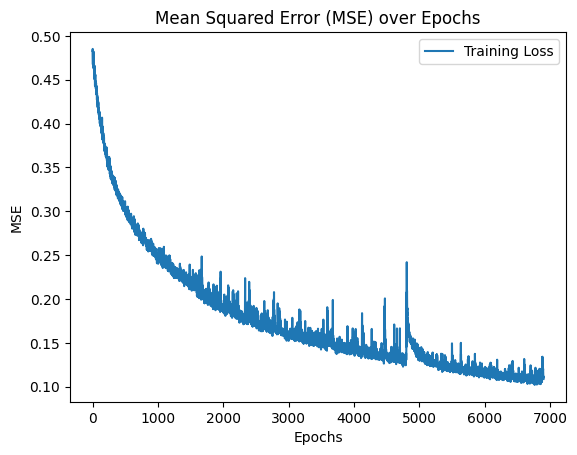

The function training took 136.124575 seconds.


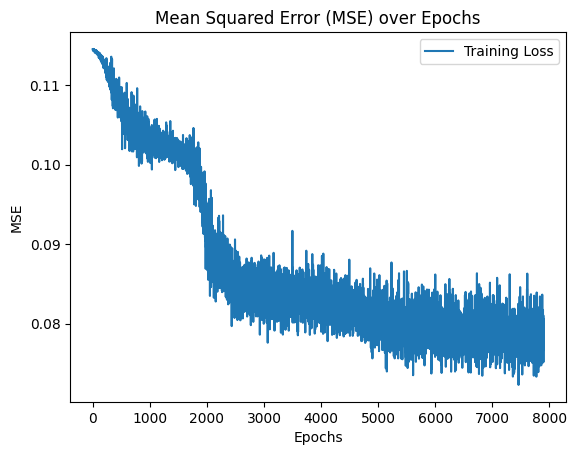

low fidelity NN
Test MSE: 0.028788165470214712
R^2: 0.76892227635286
Final model
Test MSE: 0.08237195418809666
R^2: 0.27232476270539807


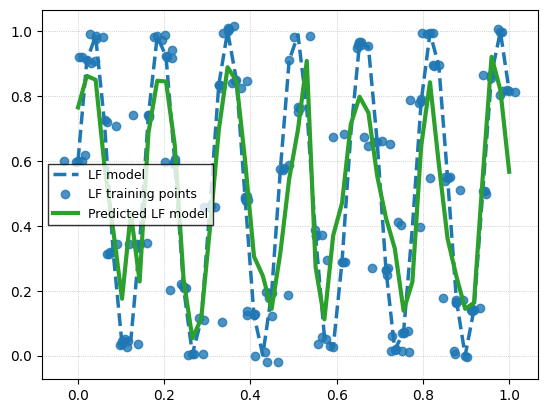

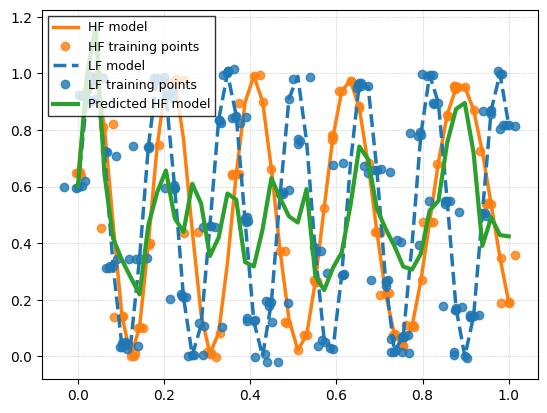

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.845833 seconds.


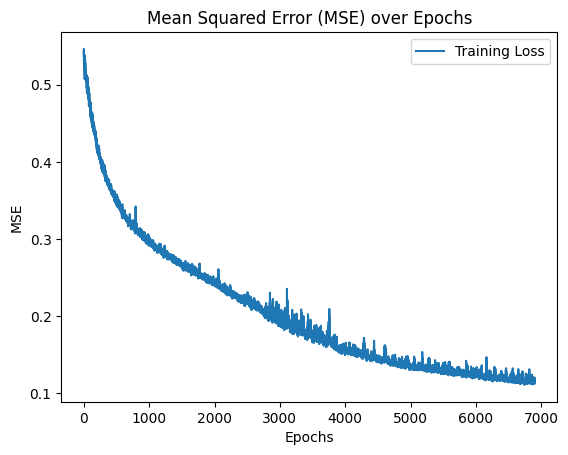

The function training took 145.216224 seconds.


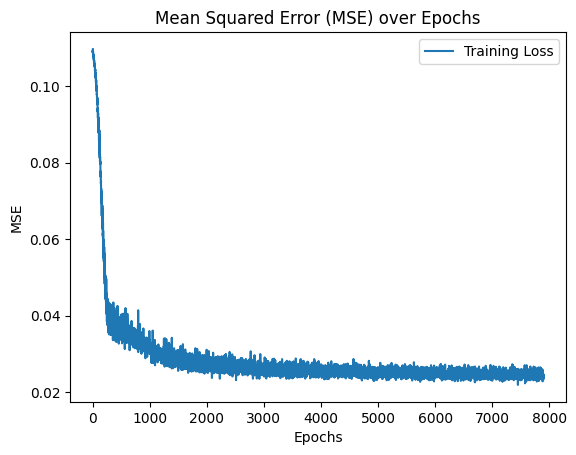

low fidelity NN
Test MSE: 0.008970263271898697
R^2: 0.9211485992401296
Final model
Test MSE: 0.017111899931402982
R^2: 0.8488331864179017


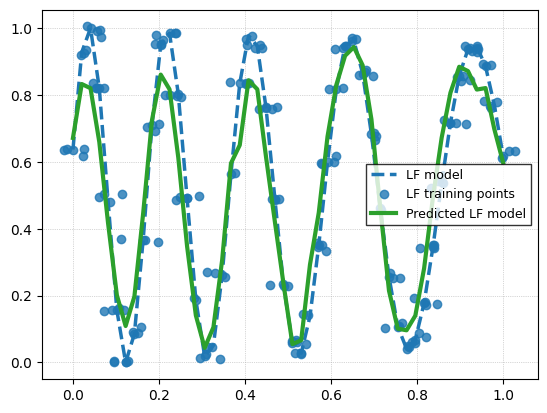

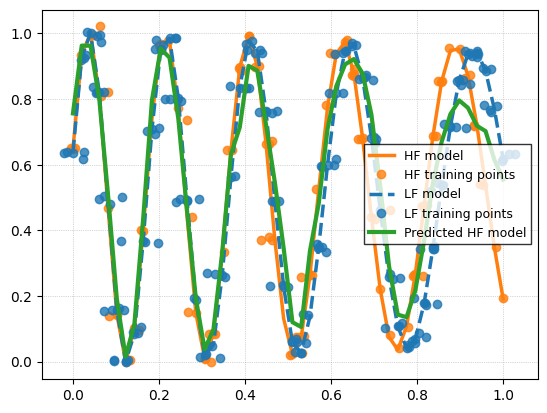

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 132.895476 seconds.


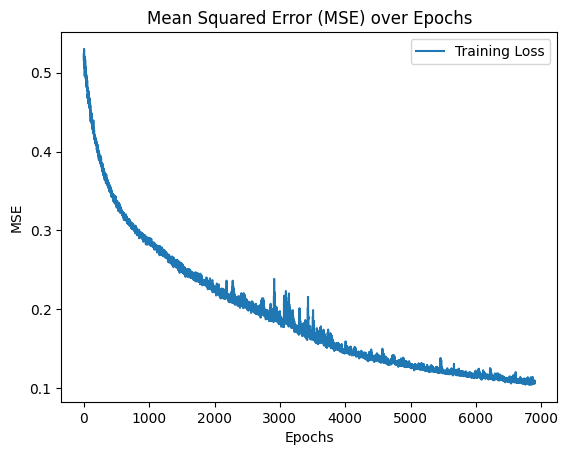

The function training took 143.821080 seconds.


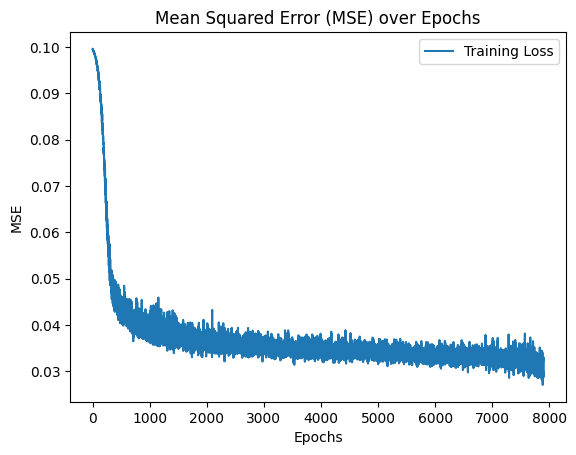

low fidelity NN
Test MSE: 0.0067249916736654815
R^2: 0.9429060671588488
Final model
Test MSE: 0.019699904095960487
R^2: 0.8259707138308918


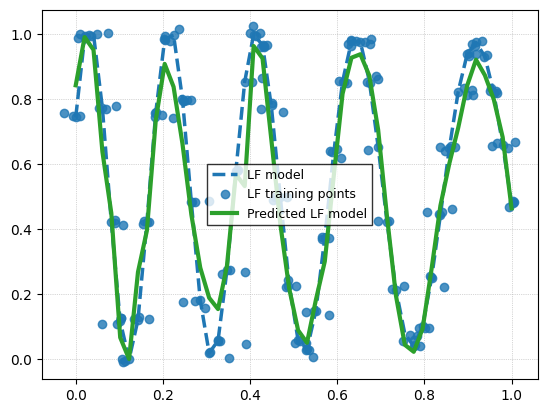

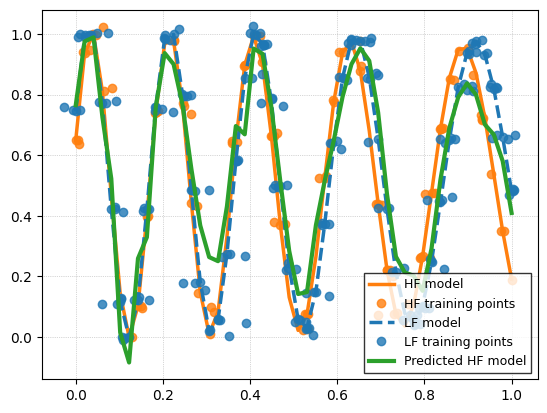

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 130.881761 seconds.


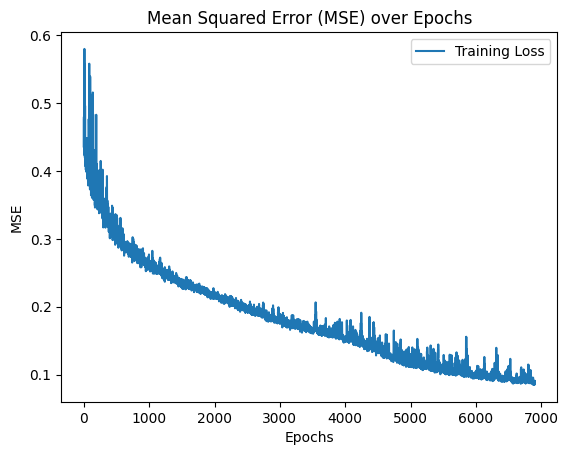

The function training took 144.842151 seconds.


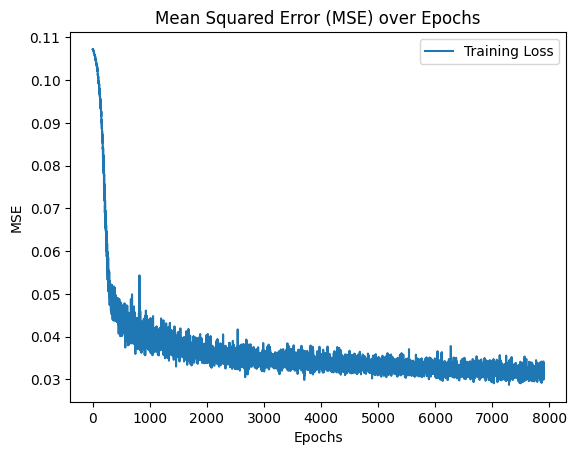

low fidelity NN
Test MSE: 0.0182080840771662
R^2: 0.8427014568649867
Final model
Test MSE: 0.017252140264046815
R^2: 0.8475943009460111


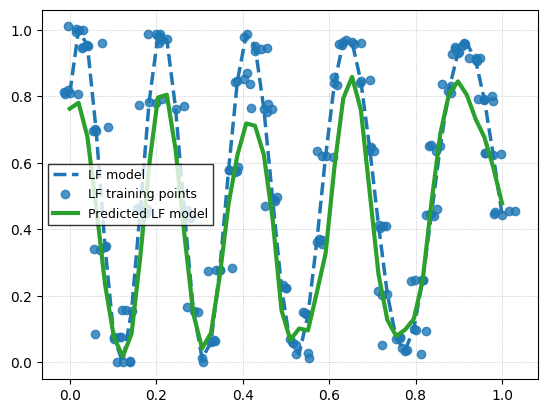

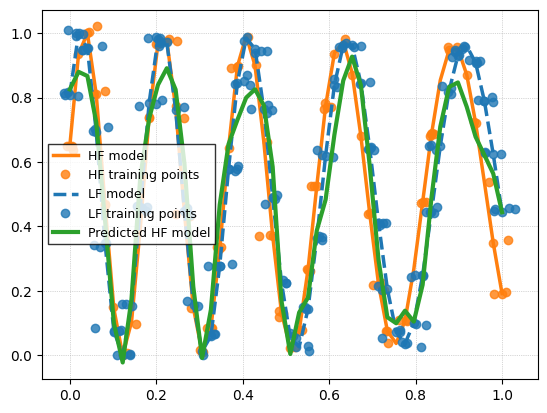

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.610376 seconds.


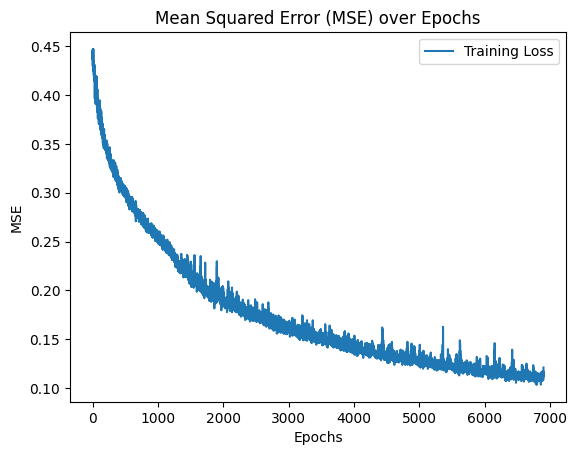

The function training took 144.174938 seconds.


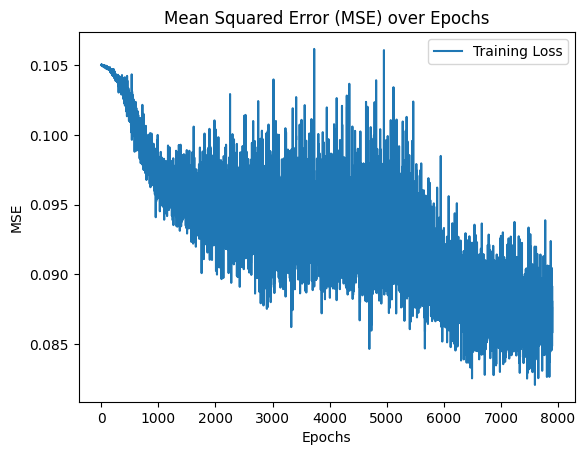

low fidelity NN
Test MSE: 0.049741922628281816
R^2: 0.600884597243834
Final model
Test MSE: 0.10627953020421028
R^2: 0.061124831586388706


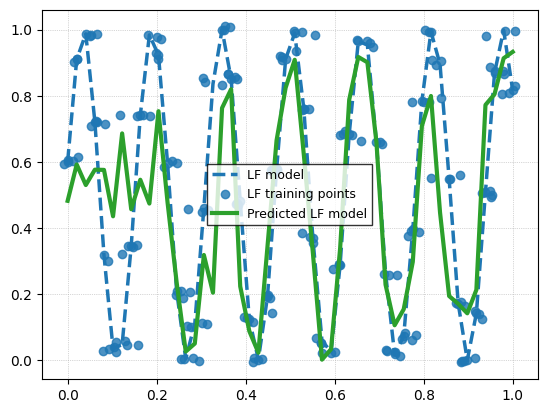

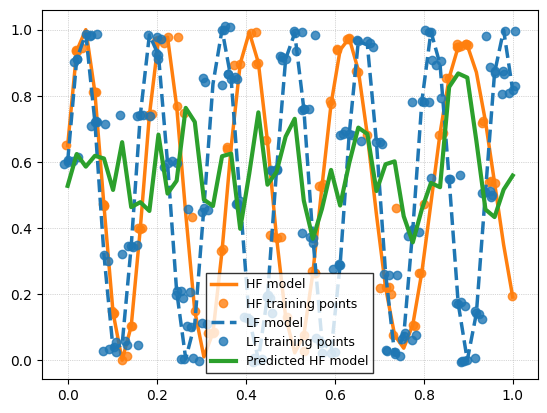

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.601148 seconds.


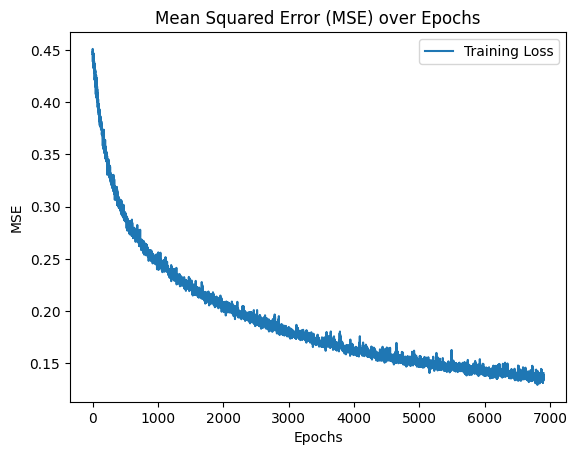

The function training took 143.413239 seconds.


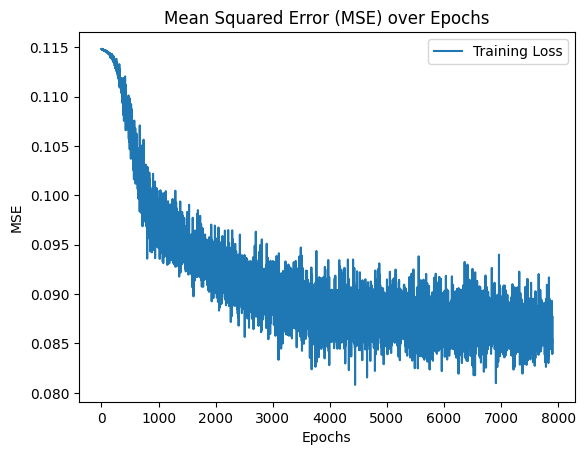

low fidelity NN
Test MSE: 0.08665881243320497
R^2: 0.23485120657955294
Final model
Test MSE: 0.09083016193334144
R^2: 0.19760481234397453


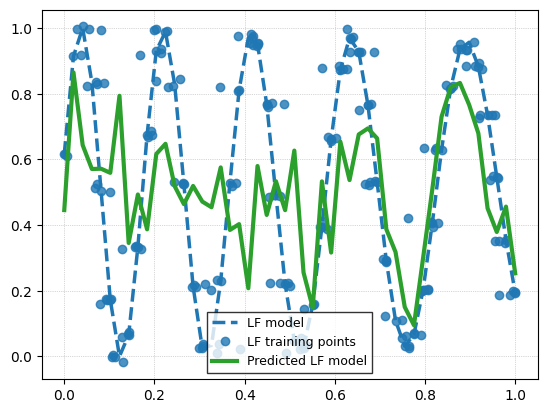

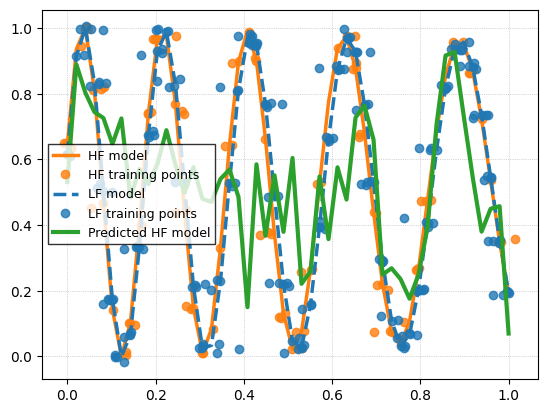

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.059491 seconds.


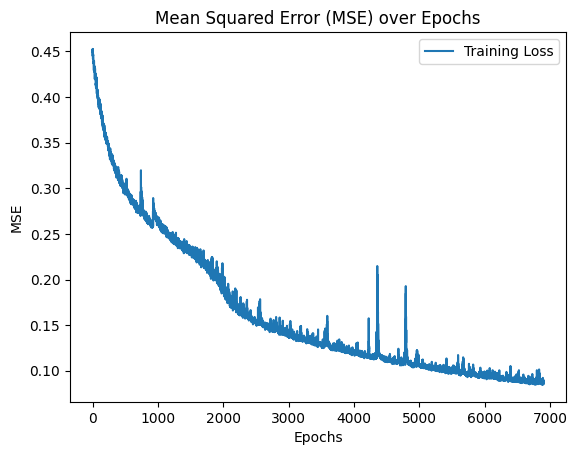

The function training took 143.121618 seconds.


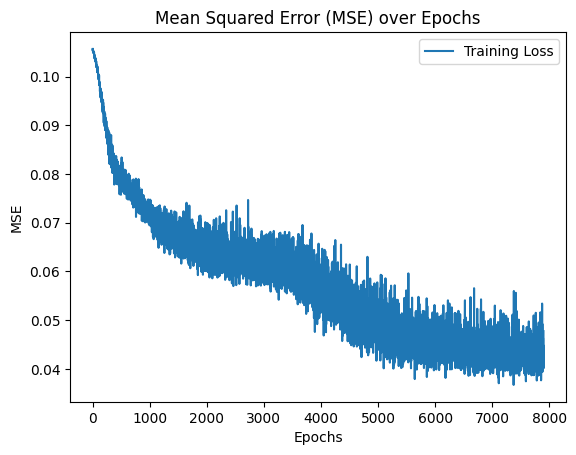

low fidelity NN
Test MSE: 0.005641201708085847
R^2: 0.9520210830591083
Final model
Test MSE: 0.033993124987603845
R^2: 0.6997041585870958


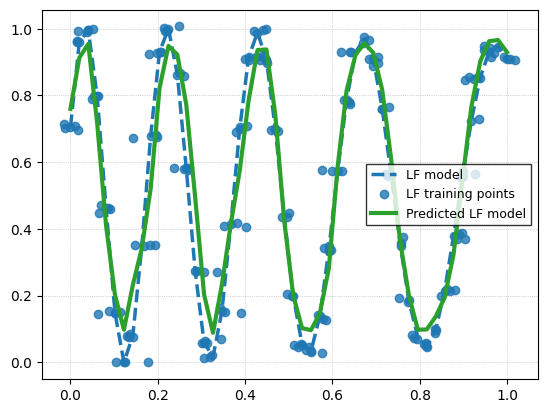

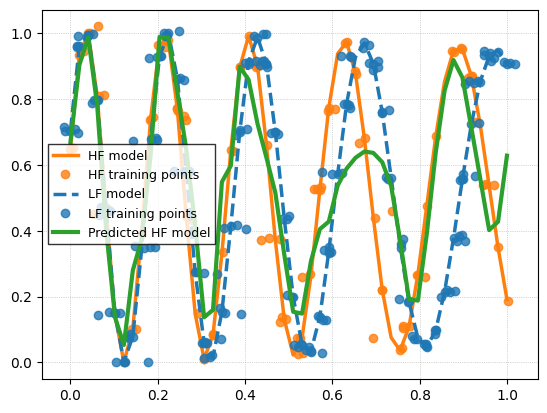

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 130.996887 seconds.


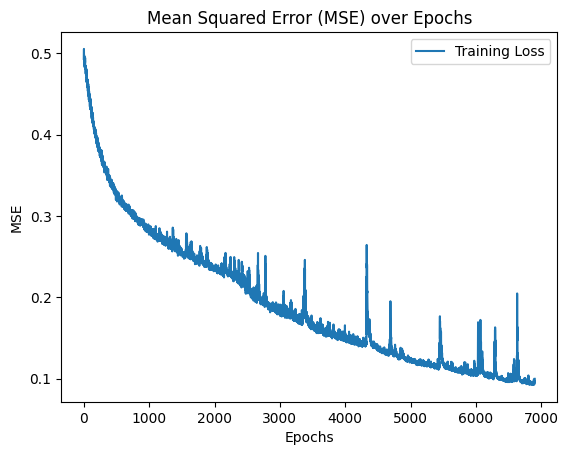

The function training took 143.361967 seconds.


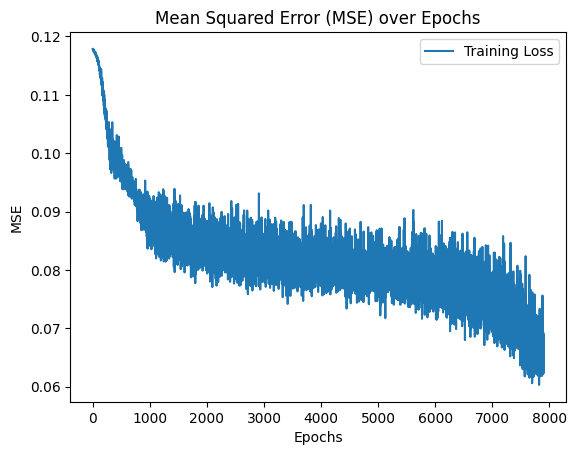

low fidelity NN
Test MSE: 0.011393316335465637
R^2: 0.9036474524744768
Final model
Test MSE: 0.04788946541868392
R^2: 0.5769436520484027


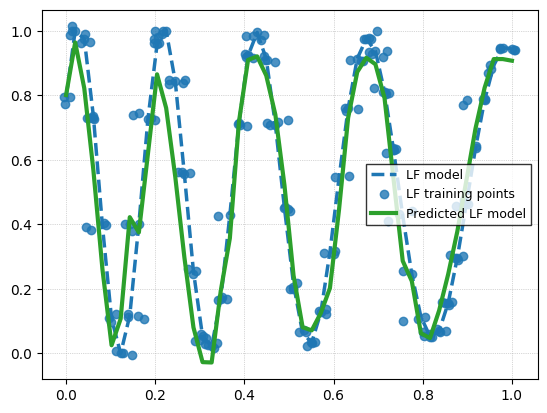

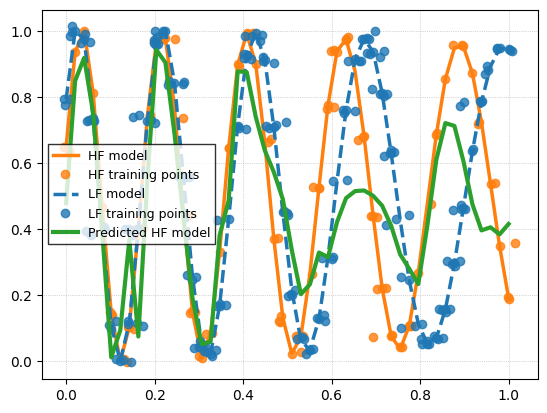

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.454533 seconds.


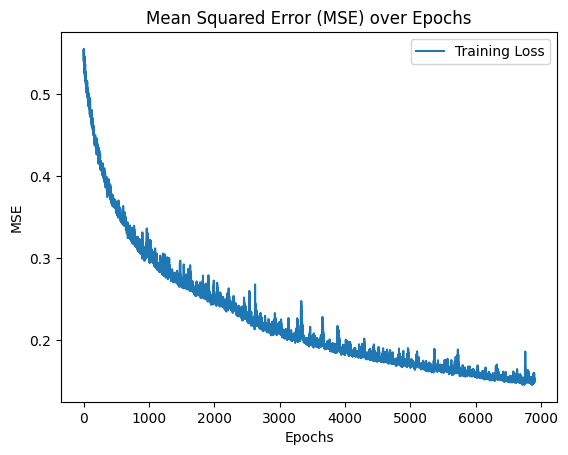

The function training took 142.815946 seconds.


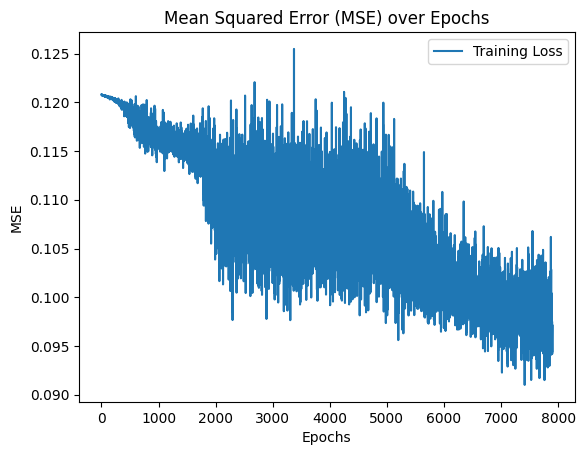

low fidelity NN
Test MSE: 0.020831879892911263
R^2: 0.8329052624704547
Final model
Test MSE: 0.08731918610313234
R^2: 0.22862083224498364


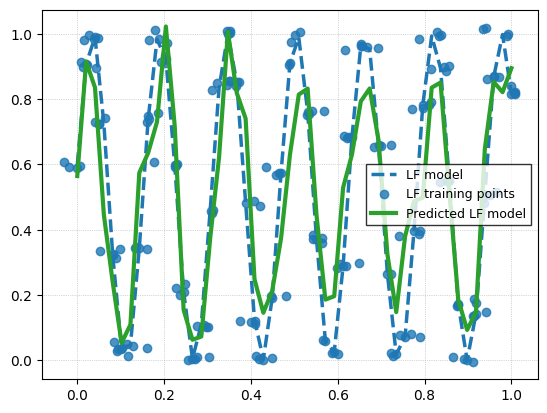

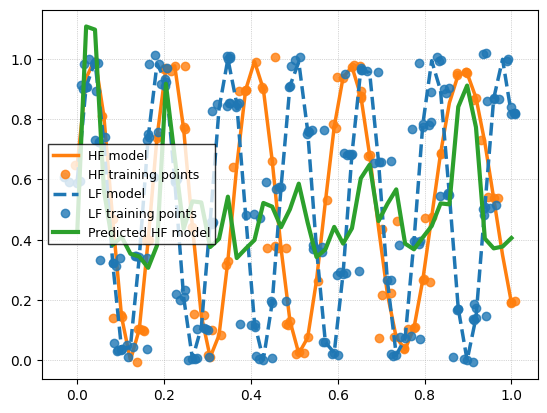

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.515663 seconds.


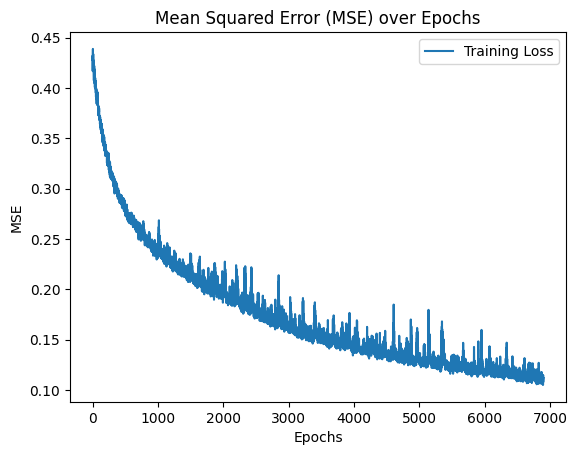

The function training took 142.424284 seconds.


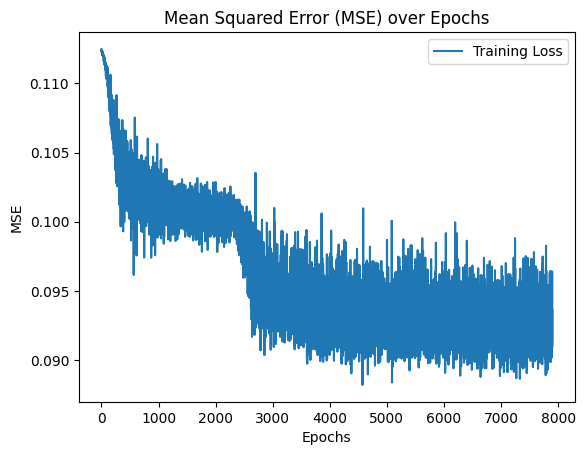

low fidelity NN
Test MSE: 0.026611735953288737
R^2: 0.7860991730137048
Final model
Test MSE: 0.09562527082949634
R^2: 0.15524473920676107


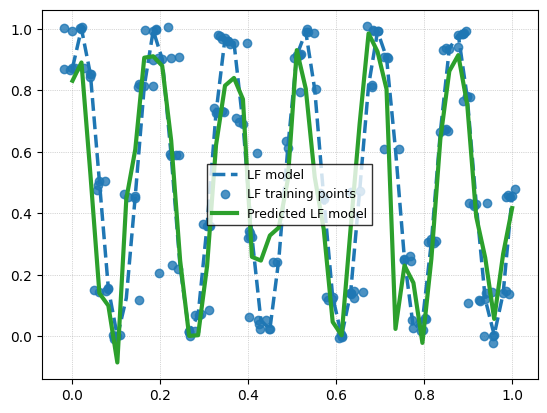

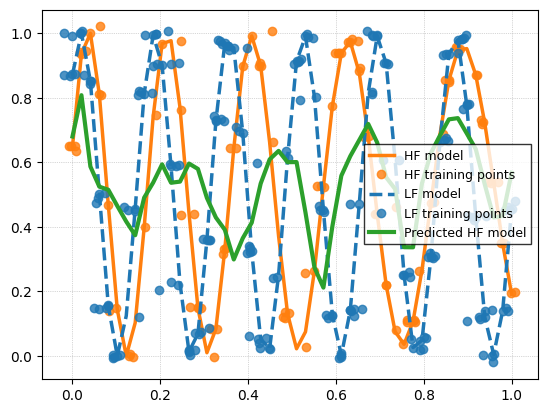

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.570661 seconds.


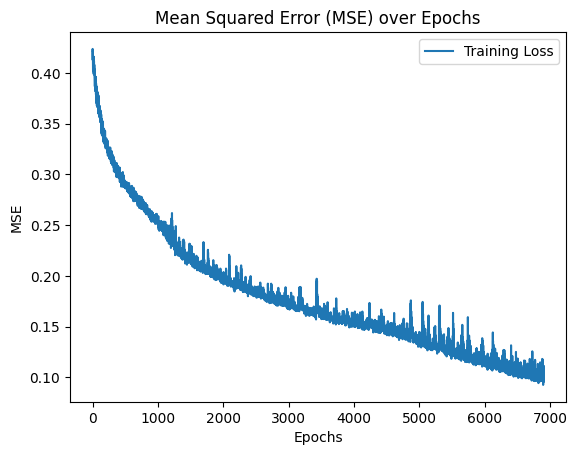

The function training took 143.675661 seconds.


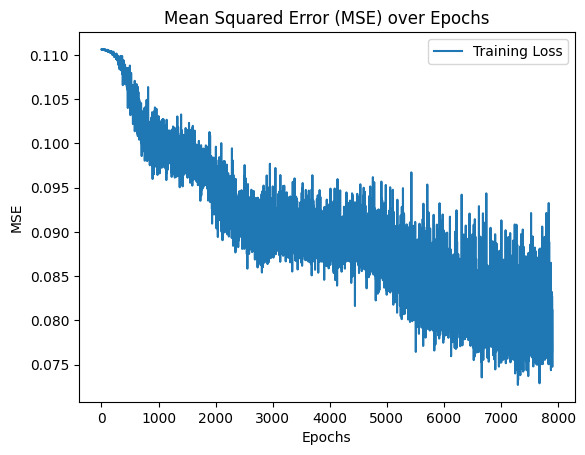

low fidelity NN
Test MSE: 0.019306710613952817
R^2: 0.8486623642717093
Final model
Test MSE: 0.07222238911328384
R^2: 0.3619861923394021


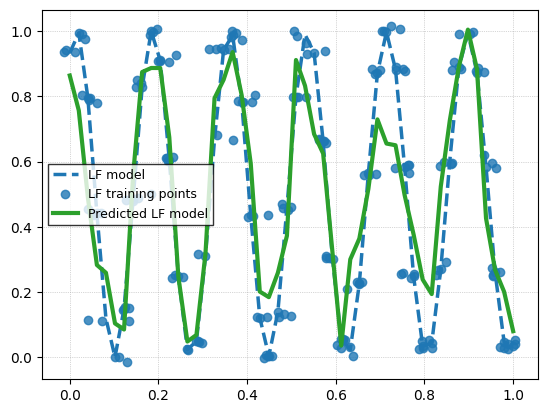

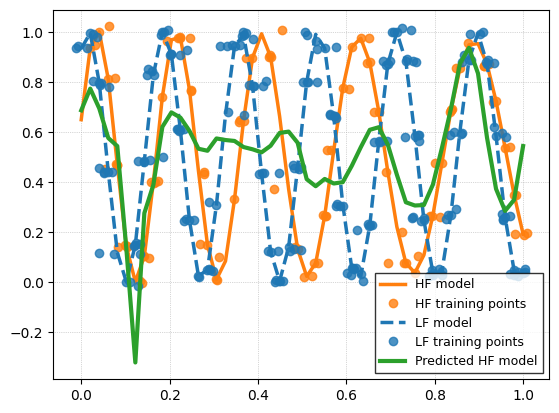

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 132.317177 seconds.


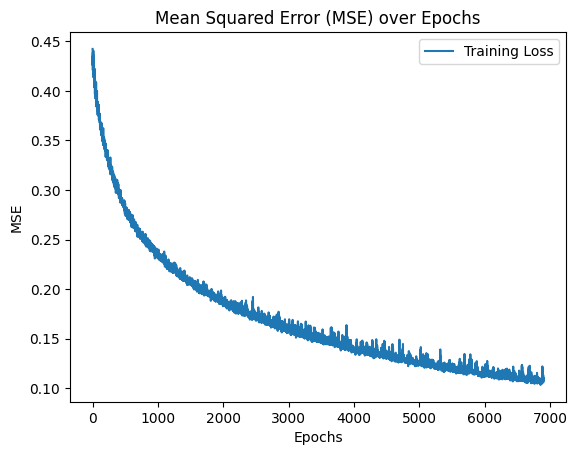

The function training took 142.495125 seconds.


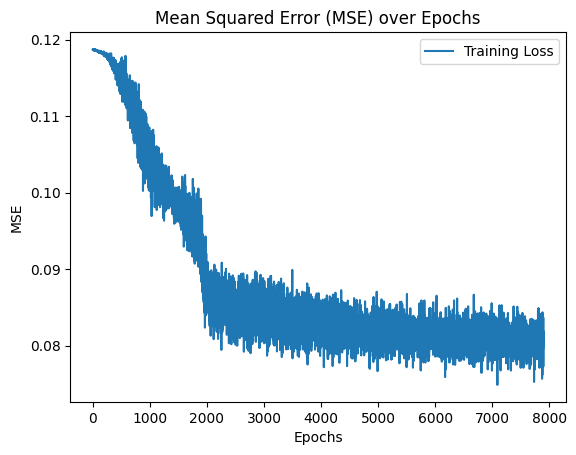

low fidelity NN
Test MSE: 0.028099025104225236
R^2: 0.7687197678248128
Final model
Test MSE: 0.07439442978561846
R^2: 0.34279834828212197


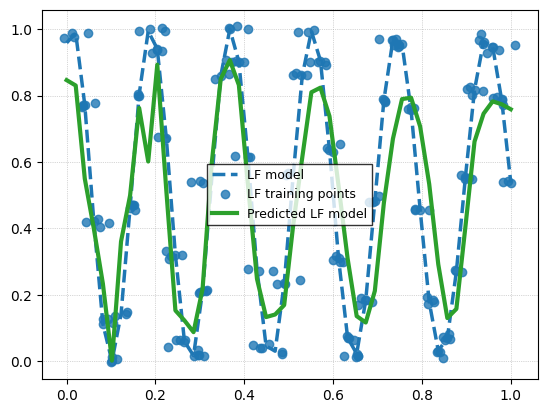

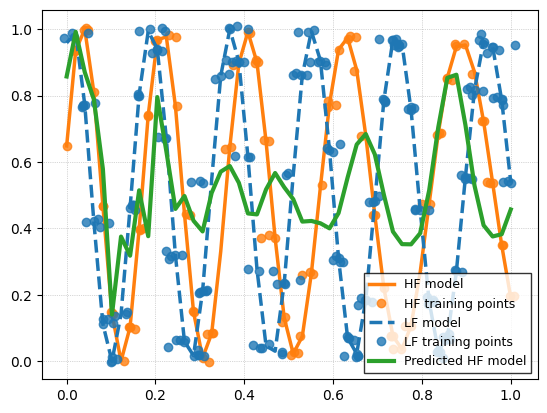

Empty DataFrame
Columns: [Discretization, diffusion, R2]
Index: []
Empty DataFrame
Columns: [Discretization, diffusion, MSE]
Index: []


In [9]:
# Name of the folder
folder_name = "2_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []

    r2_HF_list = []
    r2_LF_list = []

    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
        
                print(
                f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                )
                
                print(
                f"********************  # Diff: = {diffusion[d]}  ********************"
                )
                
                print(
                f"********************  # NHF: = {nhf}  ********************"
                )
                print(
                f"********************  # NLF: = {nlf}  ********************"
                )
                ### import of the Low Fidelity component of the dataset 
                file_path_LF = "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

                # selection and normalization of the dataset
                U_LF_test = U_LF_test[:,- 1,int(4*(Discretizations[m]-1)/9),int(4*(Discretizations[m]-1)/9)] # indexes to find the same temporal (last) and spatial points        
                U_LF_test = normalization(U_LF_test)
                reaction_LF_test = normalization(reaction_LF_test)
                
                # transformation of the Low fidelity test set
                reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                U_LF_test_original=U_LF_test # keep the original for later evaluation and representation 
                
                # dataset augmentation adding a noise
                noise_std1=[0.02,0.01,0.02,0.01]
                noise_std2=[0.01,0.005,0.01,0.005]
                (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                
                # randomization and selection of the training set
                permutation = np.random.permutation(len(reaction_HF_test))
                reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                U_HF = U_HF_test[permutation][0:nhf]
                permutation = np.random.permutation(len(reaction_LF_test))
                reaction_LF = reaction_LF_test[permutation][0:nlf]
                U_train_LF = U_LF_test[permutation][0:nlf]

                # transformation of the dataset
                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                
                ##########################      Neural Network     ##########################
                K.clear_session()
                
                # parameters 
                bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
                best_params={'kernel_init': 'uniform', 
                             'l2weight': 0.005395541657336886, 
                             'lr': 0.0025412188591473228, 
                             'nodes': 12.0, 
                             'opt': 'Adamax'}


                # Multifidelity network 
                names=["LF","HF"]
                params=[bestLF_params, best_params]
                data_train=[reaction_LF, reaction_HF]
                output_train=[U_train_LF,U_HF]

                definition_2steps = {
                                    "network_type": "2step",
                                    "names": names,
                                    "params": params,
                                    "data_train": data_train,
                                    "output_train": output_train,
                                    "N": Nepo,
                                    "n": batch_size,
                                    "train": True,
                                    "do_HPO": False,
                                    "verbose": False
                                    }
                model= NetworkFactory.build_network(**definition_2steps)
  

  
                ULF = model.model_list[0].prediction(reaction_LF_test_original)
                print("low fidelity NN")
                
                (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                test_mse_LF_list.append(test_mse_LF)
                r2_LF_list.append(r2_LF)

                input_HF = np.concatenate(
                    (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                )  # <- TRAINING INPUT for the second NN: NN_HF

                input_HF_train = np.concatenate(
                    (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                ) 
                print("Final model")
                (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original)                
                test_mse_HF_list.append(test_mse_HF)
                r2_HF_list.append(r2_HF)
                
                
                # plots of the model

                plt.figure()

                plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                plt.plot(
                    reaction_LF[:, 0],
                    U_train_LF,
                    "o",
                    markersize=6,
                    color="#1F77B4",
                    alpha=0.8,
                    label="LF training points",
                )

                plt.plot(
                    reaction_LF_test_original[:, 0],
                    model.model_list[0].prediction(reaction_LF_test_original),
                    color="#2CA02C",
                    linestyle="-",
                    linewidth=3,
                    label="Predicted LF model",
                )

                plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                plt.show()
                


                plt.figure()

                plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

                plt.plot(
                    input_HF_train[:, 0],
                    U_HF,
                    "o",
                    markersize=6,
                    color="#FF7F0E",
                    alpha=0.8,
                    label="HF training points",
                )

                plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                plt.plot(
                    reaction_LF[:,0],
                    U_train_LF,
                    "o",
                    markersize=6,
                    color="#1F77B4",
                    alpha=0.8,
                    label="LF training points",
                )

                plt.plot(
                    input_HF[:, 0],
                    model.model_list[1].prediction(input_HF),
                    color="#2CA02C",
                    linestyle="-",
                    linewidth=3,
                    label="Predicted HF model",
                )

                plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                plt.show()
                
                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                # r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)

                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                # r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)

                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                # mse_LF_df = pd.concat([mse_LF_df, pd.DataFrame([new])], ignore_index=True)

                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                # mse_HF_df = pd.concat([mse_HF_df, pd.DataFrame([new])], ignore_index=True)
            
            
                # # save the model
                # if not r2_HF_list[:-1]:
                #     model.save(str(Discretizations[m]),folder_path)
                # elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                #     model.save(str(Discretizations[m]),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

## Save the output

In [ ]:
os.makedirs("MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class")

r2_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class'